In [1]:
from pathlib import Path
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr, pearsonr

In [ ]:
PROJECT_ROOT = Path("/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps")


BSDS_TRAIN = PROJECT_ROOT / "data" / "BSDS300" / "images" / "train"
BSDS_TEST  = PROJECT_ROOT / "data" / "BSDS300" / "images" / "test"
GOPRO_SUBSET  = PROJECT_ROOT / "data" / "GoPro_dataset_custom" / "sharp"

IMAGENET_SUBSET = PROJECT_ROOT / "data" / "imagenet_subset"

train_dirs = [BSDS_TRAIN, BSDS_TEST, GOPRO_SUBSET, IMAGENET_SUBSET]

for d in train_dirs:
    print(d, d.exists())

/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/data/BSDS300/images/train True
/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/data/BSDS300/images/test True
/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/data/GoPro_dataset_custom/sharp True
/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/data/imagenet_subset True


In [5]:
train_image_paths = []

extensions = ["*.jpg", "*.jpeg", "*.png", "*.JPEG", "*.JPG", "*.PNG"]

for d in train_dirs:
    for ext in extensions:
        train_image_paths.extend(list(d.rglob(ext)))

print("num training images:", len(train_image_paths))
print(train_image_paths[:5])

num training images: 3322
[PosixPath('/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/data/BSDS300/images/train/176019.jpg'), PosixPath('/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/data/BSDS300/images/train/112082.jpg'), PosixPath('/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/data/BSDS300/images/train/108041.jpg'), PosixPath('/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/data/BSDS300/images/train/187039.jpg'), PosixPath('/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/data/BSDS300/images/train/260081.jpg')]


In [6]:
def load_grayscale_image(path, image_size=64):
    img = Image.open(path).convert("L")  # grayscale
    img = img.resize((image_size, image_size))
    arr = np.array(img).astype(np.float32) / 255.0
    return arr

def extract_patches(img, patch_size=8, stride=4):
    patches = []
    H, W = img.shape
    for i in range(0, H - patch_size + 1, stride):
        for j in range(0, W - patch_size + 1, stride):
            patch = img[i:i+patch_size, j:j+patch_size].reshape(-1)
            patches.append(patch)
    return np.array(patches, dtype=np.float32)

In [7]:
all_patches = []

# for proof of concept, cap number of images if needed
max_train_images = len(train_image_paths)

sampled_paths = random.sample(train_image_paths, max_train_images)

for path in sampled_paths:
    img = load_grayscale_image(path, image_size=64)
    patches = extract_patches(img, patch_size=8, stride=4)
    all_patches.append(patches)

all_patches = np.concatenate(all_patches, axis=0)

print("patch matrix shape:", all_patches.shape)

patch matrix shape: (747450, 64)


In [8]:
scaler = StandardScaler()
all_patches_scaled = scaler.fit_transform(all_patches)

print(all_patches_scaled.shape)

(747450, 64)


In [10]:
gmm = GaussianMixture(
    n_components=100,
    covariance_type="diag",
    reg_covar=1e-5,
    random_state=42,
    max_iter=500,
    tol=1e-5,
    verbose=1
)

gmm.fit(all_patches_scaled.astype("float64"))
print("GMM trained.")

Initialization 0
  Iteration 10
  Iteration 20
  Iteration 30
  Iteration 40
  Iteration 50
  Iteration 60
  Iteration 70
  Iteration 80
  Iteration 90
  Iteration 100
  Iteration 110
  Iteration 120
  Iteration 130
  Iteration 140
  Iteration 150
  Iteration 160
  Iteration 170
  Iteration 180
  Iteration 190
  Iteration 200
  Iteration 210
  Iteration 220
  Iteration 230
  Iteration 240
  Iteration 250
  Iteration 260
  Iteration 270
  Iteration 280
  Iteration 290
  Iteration 300
  Iteration 310
  Iteration 320
  Iteration 330
  Iteration 340
  Iteration 350
  Iteration 360
  Iteration 370
  Iteration 380
  Iteration 390
  Iteration 400
  Iteration 410
  Iteration 420
  Iteration 430
  Iteration 440
  Iteration 450
  Iteration 460
  Iteration 470
Initialization converged.
GMM trained.


In [11]:
import joblib

joblib.dump(gmm, "gmm_100_diag_reg1e-5.pkl")
joblib.dump(scaler, "patch_scaler.pkl")

['patch_scaler.pkl']

## Testing with 500 iteration GMM (100 components)

In [24]:
def image_complexity_nll(path, image_size=64, patch_size=8, stride=4):
    img = load_grayscale_image(path, image_size=image_size)
    patches = extract_patches(img, patch_size=patch_size, stride=stride)
    patches_scaled = scaler.transform(patches)

    log_probs = gmm.score_samples(patches_scaled)
    nll = -log_probs

    top_k = max(1, int(0.1 * len(nll)))
    sorted_nll = np.sort(nll)

    return {
        "mean_nll": float(np.mean(nll)),
        "std_nll": float(np.std(nll)),
        "max_nll": float(np.max(nll)),
        "median_nll": float(np.median(nll)),
        "p90_nll": float(np.percentile(nll, 90)),
        "top10_mean_nll": float(np.mean(sorted_nll[-top_k:])),
    }

In [25]:
# Pick any one run folder; y0_*.png should correspond to the degraded observation.
DDR_ROOT = PROJECT_ROOT / "external" / "ddrm"
REF_RUN_DIR = DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k100_strongerblur"

eval_image_paths = sorted(list(REF_RUN_DIR.glob("y0_*.png")))

print("num eval degraded images:", len(eval_image_paths))
for p in eval_image_paths:
    print(p.name)

num eval degraded images: 22
y0_0.png
y0_1.png
y0_10.png
y0_11.png
y0_12.png
y0_13.png
y0_14.png
y0_15.png
y0_16.png
y0_17.png
y0_18.png
y0_19.png
y0_2.png
y0_20.png
y0_21.png
y0_3.png
y0_4.png
y0_5.png
y0_6.png
y0_7.png
y0_8.png
y0_9.png


In [3]:
kstar_labels = {
    "y0_0.png": 44,
    "y0_1.png": 48,
    "y0_2.png": 63,
    "y0_3.png": 38,
    "y0_4.png": 38,
    "y0_5.png": 41,
    "y0_6.png": 68,
    "y0_7.png": 56,
    "y0_8.png": 48,
    "y0_9.png": 56,
    "y0_10.png": 73,
    "y0_11.png": 32,
    "y0_12.png": 42,
    "y0_13.png": 41,
    "y0_14.png": 59,
    "y0_15.png": 46,
    "y0_16.png": 39,
    "y0_17.png": 44,
    "y0_18.png": 63,
    "y0_19.png": 44,
    "y0_20.png": 41,
    "y0_21.png": 31,
}



In [27]:
import re

def extract_image_idx(filename):
    # works for y0_0.png, orig_3.png, etc.
    m = re.search(r"_(\d+)\.png$", filename)
    if m is None:
        raise ValueError(f"Could not extract image index from {filename}")
    return int(m.group(1))

rows = []

for path in eval_image_paths:
    idx = extract_image_idx(path.name)
    orig_name = f"y0_{idx}.png"   # maps degraded image back to your k* labels

    stats = image_complexity_nll(path, image_size=64, patch_size=8, stride=4)

    rows.append({
        "image": path.name,          # now this will be y0_*.png
        "image_idx": idx,
        "mean_nll": stats["mean_nll"],
        "std_nll": stats["std_nll"],
        "max_nll": stats["max_nll"],
        "median_nll": stats["median_nll"],
        "p90_nll": stats["p90_nll"],
        "top10_mean_nll": stats["top10_mean_nll"],
        "kstar": kstar_labels[orig_name],
    })

rows

[{'image': 'y0_0.png',
  'image_idx': 0,
  'mean_nll': -45.10405999897039,
  'std_nll': 42.324478067981566,
  'max_nll': 48.87896257020031,
  'median_nll': -65.98028351606374,
  'p90_nll': 17.484487793010572,
  'top10_mean_nll': 31.966355086428702,
  'kstar': 44},
 {'image': 'y0_1.png',
  'image_idx': 1,
  'mean_nll': -9.864018508353077,
  'std_nll': 33.49812315091552,
  'max_nll': 61.23517347344872,
  'median_nll': -3.0652692708751594,
  'p90_nll': 25.29744984017691,
  'top10_mean_nll': 39.51677110197441,
  'kstar': 48},
 {'image': 'y0_10.png',
  'image_idx': 10,
  'mean_nll': 12.83685763094015,
  'std_nll': 30.20763520200355,
  'max_nll': 65.6539921249078,
  'median_nll': 18.528662463048917,
  'p90_nll': 44.14443665863403,
  'top10_mean_nll': 52.49846129699026,
  'kstar': 73},
 {'image': 'y0_11.png',
  'image_idx': 11,
  'mean_nll': 6.990758215378017,
  'std_nll': 19.857608939269628,
  'max_nll': 57.55989556973495,
  'median_nll': 9.144757989142663,
  'p90_nll': 31.69440032652978,
  

In [28]:
import pandas as pd

df = pd.DataFrame(rows).sort_values("image").reset_index(drop=True)
df.to_csv("gmm_results_gopro.csv", index=False)
print("saved gmm_results_gopro.csv")
df

saved gmm_results_gopro.csv


,image,image_idx,mean_nll,std_nll,max_nll,median_nll,p90_nll,top10_mean_nll,kstar
0,y0_0.png,0,-45.104060,42.324478,48.878963,-65.980284,17.484488,31.966355,44
1,y0_1.png,1,-9.864019,33.498123,61.235173,-3.065269,25.297450,39.516771,48
2,y0_10.png,10,12.836858,30.207635,65.653992,18.528662,44.144437,52.498461,73
3,y0_11.png,11,6.990758,19.857609,57.559896,9.144758,31.694400,41.166122,32
4,y0_12.png,12,-48.815440,46.534224,55.627849,-71.424817,32.995226,42.663820,42
5,y0_13.png,13,-10.616323,34.783118,56.452223,-2.129521,28.076370,37.242291,41
6,y0_14.png,14,-1.102318,38.179453,73.859617,8.068074,42.660980,51.262194,59
7,y0_15.png,15,15.348925,26.335934,66.393233,13.709198,51.145638,58.372783,46
8,y0_16.png,16,4.964925,30.309460,62.503530,7.495607,42.560843,49.713622,39
9,y0_17.png,17,-9.061398,29.907464,65.962459,-6.759590,25.763458,41.986012,44


In [29]:
from scipy.stats import pearsonr, spearmanr

features = ["mean_nll", "std_nll", "max_nll", "median_nll", "p90_nll", "top10_mean_nll"]

for feat in features:
    x = df[feat].values
    y = df["kstar"].values

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_r, spearman_p = spearmanr(x, y)

    print(f"{feat} vs k*")
    print(f"  Pearson:  r={pearson_r:.4f}, p={pearson_p:.4f}")
    print(f"  Spearman: r={spearman_r:.4f}, p={spearman_p:.4f}")
    print()

mean_nll vs k*
  Pearson:  r=0.3925, p=0.0708
  Spearman: r=0.4108, p=0.0576

std_nll vs k*
  Pearson:  r=0.1311, p=0.5610
  Spearman: r=0.1286, p=0.5684

max_nll vs k*
  Pearson:  r=0.5830, p=0.0044
  Spearman: r=0.6623, p=0.0008

median_nll vs k*
  Pearson:  r=0.3841, p=0.0776
  Spearman: r=0.5309, p=0.0110

p90_nll vs k*
  Pearson:  r=0.5274, p=0.0117
  Spearman: r=0.5139, p=0.0144

top10_mean_nll vs k*
  Pearson:  r=0.5802, p=0.0046
  Spearman: r=0.6198, p=0.0021



In [21]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr

features = ["mean_nll", "std_nll", "max_nll", "median_nll", "p90_nll", "top10_mean_nll"]

rows = []

for feat in features:
    x = df[feat].values
    y = df["kstar"].values

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_r, spearman_p = spearmanr(x, y)

    rows.append({
        "feature": feat,
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p
    })

corr_df = pd.DataFrame(rows)
corr_df

,feature,pearson_r,pearson_p,spearman_r,spearman_p
0,mean_nll,0.392475,0.070808,0.410767,0.057564
1,std_nll,0.131050,0.561027,0.128613,0.568399
2,max_nll,0.582977,0.004406,0.662327,0.000784
3,median_nll,0.384116,0.077576,0.530881,0.011019
4,p90_nll,0.527378,0.011661,0.513884,0.014427
5,top10_mean_nll,0.580241,0.004641,0.619834,0.002092


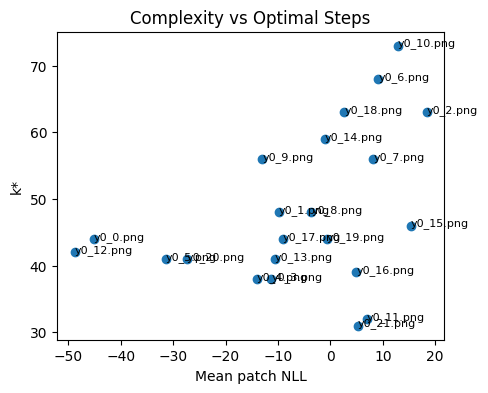

In [22]:
plt.figure(figsize=(5,4))
plt.scatter(df["mean_nll"], df["kstar"])
for _, row in df.iterrows():
    plt.annotate(row["image"], (row["mean_nll"], row["kstar"]), fontsize=8)
plt.xlabel("Mean patch NLL")
plt.ylabel("k*")
plt.title("Complexity vs Optimal Steps")
plt.show()

## Check correlation between human eval and steps

In [1]:
import pandas as pd

df_gopro_int = pd.read_csv("../data/human_evals/human_complexity_labels gopro intuition.csv")

print(df_gopro_int.shape)
df_gopro_int.head()

(22, 2)


,image_name,human_score
0,y0_0.png,3
1,y0_1.png,9
2,y0_2.png,10
3,y0_3.png,8
4,y0_4.png,5


In [4]:
kstar_df = pd.DataFrame([
    {"image_name": k, "kstar": v}
    for k, v in kstar_labels.items()
])

kstar_df.head()

,image_name,kstar
0,y0_0.png,44
1,y0_1.png,48
2,y0_2.png,63
3,y0_3.png,38
4,y0_4.png,38


In [6]:
df_intuition = pd.merge(df_gopro_int, kstar_df, on="image_name")

print(df_intuition.shape)
df_intuition.head()

(22, 3)


,image_name,human_score,kstar
0,y0_0.png,3,44
1,y0_1.png,9,48
2,y0_2.png,10,63
3,y0_3.png,8,38
4,y0_4.png,5,38


In [8]:
from scipy.stats import pearsonr, spearmanr

pearson = pearsonr(df_intuition["human_score"], df_intuition["kstar"])
spearman = spearmanr(df_intuition["human_score"], df_intuition["kstar"])

print("Human score vs k*")
print(f" Pearson:  r={pearson.statistic:.4f}, p={pearson.pvalue:.4f}")
print(f" Spearman: r={spearman.statistic:.4f}, p={spearman.pvalue:.4f}")

Human score vs k*
 Pearson:  r=0.3042, p=0.1688
 Spearman: r=0.3128, p=0.1563


### Results are bad with human eval :(

## Testing with 200 iteration GMM (100 components)

In [11]:
import joblib

gmm = joblib.load("../../../notebooks/checkpoints/gmm_100_200iter_reg1-5/gmm_100_diag_reg1e-5_200iter.pkl")
scaler = joblib.load("../../../notebooks/checkpoints/gmm_100_200iter_reg1-5/patch_scaler_200iter_gmm.pkl")

In [14]:
gmm.n_iter_

112

In [2]:
def load_grayscale_image(path, image_size=64):
    img = Image.open(path).convert("L")  # grayscale
    img = img.resize((image_size, image_size))
    arr = np.array(img).astype(np.float32) / 255.0
    return arr

def extract_patches(img, patch_size=8, stride=4):
    patches = []
    H, W = img.shape
    for i in range(0, H - patch_size + 1, stride):
        for j in range(0, W - patch_size + 1, stride):
            patch = img[i:i+patch_size, j:j+patch_size].reshape(-1)
            patches.append(patch)
    return np.array(patches, dtype=np.float32)

In [3]:
def image_complexity_nll(path, image_size=64, patch_size=8, stride=4):
    img = load_grayscale_image(path, image_size=image_size)
    patches = extract_patches(img, patch_size=patch_size, stride=stride)
    patches_scaled = scaler.transform(patches)

    log_probs = gmm.score_samples(patches_scaled)
    nll = -log_probs

    top_k = max(1, int(0.1 * len(nll)))
    sorted_nll = np.sort(nll)

    return {
        "mean_nll": float(np.mean(nll)),
        "std_nll": float(np.std(nll)),
        "max_nll": float(np.max(nll)),
        "median_nll": float(np.median(nll)),
        "p90_nll": float(np.percentile(nll, 90)),
        "top10_mean_nll": float(np.mean(sorted_nll[-top_k:])),
    }

In [6]:
# Pick any one run folder; y0_*.png should correspond to the degraded observation.
DDR_ROOT = PROJECT_ROOT / "external" / "ddrm"
REF_RUN_DIR = DDR_ROOT / "exp" / "image_samples" / "GOPRO RUNS STRONG BLUR" / "run_gopro_sharp_k100_strongerblur"

eval_image_paths = sorted(list(REF_RUN_DIR.glob("y0_*.png")))

print("num eval degraded images:", len(eval_image_paths))
for p in eval_image_paths:
    print(p.name)

num eval degraded images: 22
y0_0.png
y0_1.png
y0_10.png
y0_11.png
y0_12.png
y0_13.png
y0_14.png
y0_15.png
y0_16.png
y0_17.png
y0_18.png
y0_19.png
y0_2.png
y0_20.png
y0_21.png
y0_3.png
y0_4.png
y0_5.png
y0_6.png
y0_7.png
y0_8.png
y0_9.png


In [7]:
kstar_labels = {
    "y0_0.png": 44,
    "y0_1.png": 48,
    "y0_2.png": 63,
    "y0_3.png": 38,
    "y0_4.png": 38,
    "y0_5.png": 41,
    "y0_6.png": 68,
    "y0_7.png": 56,
    "y0_8.png": 48,
    "y0_9.png": 56,
    "y0_10.png": 73,
    "y0_11.png": 32,
    "y0_12.png": 42,
    "y0_13.png": 41,
    "y0_14.png": 59,
    "y0_15.png": 46,
    "y0_16.png": 39,
    "y0_17.png": 44,
    "y0_18.png": 63,
    "y0_19.png": 44,
    "y0_20.png": 41,
    "y0_21.png": 31,
}



In [15]:
import re

def extract_image_idx(filename):
    # works for y0_0.png, orig_3.png, etc.
    m = re.search(r"_(\d+)\.png$", filename)
    if m is None:
        raise ValueError(f"Could not extract image index from {filename}")
    return int(m.group(1))

rows = []

for path in eval_image_paths:
    idx = extract_image_idx(path.name)
    orig_name = f"y0_{idx}.png"   # maps degraded image back to your k* labels

    stats = image_complexity_nll(path, image_size=64, patch_size=8, stride=4)

    rows.append({
        "image": path.name,          # now this will be y0_*.png
        "image_idx": idx,
        "mean_nll": stats["mean_nll"],
        "std_nll": stats["std_nll"],
        "max_nll": stats["max_nll"],
        "median_nll": stats["median_nll"],
        "p90_nll": stats["p90_nll"],
        "top10_mean_nll": stats["top10_mean_nll"],
        "kstar": kstar_labels[orig_name],
    })

rows

[{'image': 'y0_0.png',
  'image_idx': 0,
  'mean_nll': -46.72021092407556,
  'std_nll': 42.273487854373116,
  'max_nll': 49.78246894270312,
  'median_nll': -63.18083532590706,
  'p90_nll': 15.473283992899155,
  'top10_mean_nll': 29.90606746645774,
  'kstar': 44},
 {'image': 'y0_1.png',
  'image_idx': 1,
  'mean_nll': -10.58664463764425,
  'std_nll': 33.45809947094351,
  'max_nll': 63.121222932723896,
  'median_nll': -4.305576301136604,
  'p90_nll': 24.45958075265621,
  'top10_mean_nll': 39.95041092986717,
  'kstar': 48},
 {'image': 'y0_10.png',
  'image_idx': 10,
  'mean_nll': 14.507475916805095,
  'std_nll': 25.691041789965738,
  'max_nll': 59.470506398477184,
  'median_nll': 20.04531794544069,
  'p90_nll': 45.14768060516452,
  'top10_mean_nll': 50.77301276606649,
  'kstar': 73},
 {'image': 'y0_11.png',
  'image_idx': 11,
  'mean_nll': 7.795924026399672,
  'std_nll': 19.019373648276943,
  'max_nll': 54.695050666504734,
  'median_nll': 9.373415110382362,
  'p90_nll': 30.21268107393033,

In [16]:
import pandas as pd

df = pd.DataFrame(rows).sort_values("image").reset_index(drop=True)
df.to_csv("gmm_200iter_results_gopro.csv", index=False)
print("saved gmm_200iter_results_gopro.csv")
df

saved gmm_200iter_results_gopro.csv


,image,image_idx,mean_nll,std_nll,max_nll,median_nll,p90_nll,top10_mean_nll,kstar
0,y0_0.png,0,-46.720211,42.273488,49.782469,-63.180835,15.473284,29.906067,44
1,y0_1.png,1,-10.586645,33.458099,63.121223,-4.305576,24.459581,39.950411,48
2,y0_10.png,10,14.507476,25.691042,59.470506,20.045318,45.147681,50.773013,73
3,y0_11.png,11,7.795924,19.019374,54.695051,9.373415,30.212681,40.462106,32
4,y0_12.png,12,-47.385194,43.821849,52.134283,-67.504698,31.075728,40.391991,42
5,y0_13.png,13,-10.812185,34.437500,51.551577,-5.165453,27.869729,38.498161,41
6,y0_14.png,14,-2.141957,36.838546,67.314476,6.292850,40.829650,49.584946,59
7,y0_15.png,15,15.424029,25.687729,65.921414,15.368058,49.618028,55.664451,46
8,y0_16.png,16,4.151519,30.383814,56.059264,7.389234,41.839057,48.500171,39
9,y0_17.png,17,-9.179005,28.679403,66.175812,-7.279233,26.358479,41.955321,44


In [17]:
from scipy.stats import pearsonr, spearmanr

features = ["mean_nll", "std_nll", "max_nll", "median_nll", "p90_nll", "top10_mean_nll"]

for feat in features:
    x = df[feat].values
    y = df["kstar"].values

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_r, spearman_p = spearmanr(x, y)

    print(f"{feat} vs k*")
    print(f"  Pearson:  r={pearson_r:.4f}, p={pearson_p:.4f}")
    print(f"  Spearman: r={spearman_r:.4f}, p={spearman_p:.4f}")
    print()

mean_nll vs k*
  Pearson:  r=0.3995, p=0.0655
  Spearman: r=0.4108, p=0.0576

std_nll vs k*
  Pearson:  r=0.0548, p=0.8087
  Spearman: r=0.0793, p=0.7257

max_nll vs k*
  Pearson:  r=0.5785, p=0.0048
  Spearman: r=0.6414, p=0.0013

median_nll vs k*
  Pearson:  r=0.3968, p=0.0675
  Spearman: r=0.4963, p=0.0188

p90_nll vs k*
  Pearson:  r=0.5390, p=0.0096
  Spearman: r=0.4958, p=0.0190

top10_mean_nll vs k*
  Pearson:  r=0.5585, p=0.0069
  Spearman: r=0.6136, p=0.0024



In [18]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr

features = ["mean_nll", "std_nll", "max_nll", "median_nll", "p90_nll", "top10_mean_nll"]

rows = []

for feat in features:
    x = df[feat].values
    y = df["kstar"].values

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_r, spearman_p = spearmanr(x, y)

    rows.append({
        "feature": feat,
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p
    })

corr_df = pd.DataFrame(rows)
corr_df

,feature,pearson_r,pearson_p,spearman_r,spearman_p
0,mean_nll,0.399479,0.065490,0.410767,0.057564
1,std_nll,0.054780,0.808683,0.079321,0.725676
2,max_nll,0.578549,0.004791,0.641363,0.001296
3,median_nll,0.396805,0.067483,0.496320,0.018802
4,p90_nll,0.538987,0.009644,0.495754,0.018959
5,top10_mean_nll,0.558465,0.006906,0.613601,0.002388
